Theory

Chain-of-Thought (CoT) prompting elicits explicit intermediate reasoning steps before the final answer. Introduced by Wei et al. (2022), CoT enables models to decompose complex problems into tractable sub-problems.

The key insight: by verbalizing reasoning, the model allocates more "compute" to harder problems. This mirrors how humans solve math problems by writing out steps. CoT dramatically improves performance on tasks requiring multi-step logic, arithmetic, and causal reasoning.

In LangGraph, CoT is implemented as a two-phase graph: first a reasoning node generates the thought chain, then an answer node extracts the final answer from that chain. This separation allows independent quality checks on each phase.

CoT Variants

Zero-shot CoT: Append "Let's think step by step"

Few-shot CoT: Provide example reasoning chains

Auto-CoT: Automatically generate demonstrations

Program-of-Thought: Generate code instead of prose

Least-to-Most: Decompose then solve sub-problems

Step-Back: Ask high-level question first

In [1]:
# ─────────────────────────────────────────────────────────
# Chain-of-Thought with LangGraph
# Pattern: Problem → Reasoning Chain → Answer Extraction
# ─────────────────────────────────────────────────────────

from typing import TypedDict, Optional, Literal
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel
import re
import json
import os
from dotenv import load_dotenv
from IPython.display import Image, display
load_dotenv()

llm = ChatOpenAI(model="gpt-4o", temperature=0.3)
llm_precise = ChatOpenAI(model="gpt-4o", temperature=0.0)

In [2]:
# ── Structured Output Schema ──────────────────────────────
class ReasoningOutput(BaseModel):
    steps: list[str]             # Individual reasoning steps
    intermediate_values: dict    # Key computed values
    reasoning_valid: bool        # Self-assessment of logic
    confidence: float            # 0.0 – 1.0

class CoTState(TypedDict):
    problem: str
    problem_type: str            # math / logic / analysis / planning
    reasoning_chain: str         # Full CoT text
    reasoning_steps: list[str]   # Parsed steps
    is_valid_reasoning: bool
    final_answer: str
    confidence: float
    retry_count: int

In [ ]:
# ── Node 1: Generate Reasoning Chain ─────────────────────
def generate_reasoning(state: CoTState) -> CoTState:
    """
    The core CoT node. Uses structured prompting to elicit
    step-by-step reasoning before committing to an answer.
    """
    system = """You are an expert problem solver. 
For every problem, you MUST:
1. Break it into numbered steps
2. Show your work at each step  
3. State intermediate conclusions clearly
4. Flag any assumptions you make
5. Write "REASONING COMPLETE" when done thinking

Format each step as:
Step N: [what you're doing]
→ [computation or logic]
→ [intermediate result]"""

    human = f"""Problem Type: {state['problem_type']}

Problem: {state['problem']}

Let's solve this step by step.
Think carefully before giving the final answer."""

    response = llm.invoke([
        SystemMessage(content=system),
        HumanMessage(content=human)
    ])
    chain = response.content

    # Parse steps from response
    steps = re.findall(r'Step \d+:.*?(?=Step \d+:|REASONING COMPLETE|$)', chain, re.DOTALL)
    # Step 1: Analyze the input
    # Some explanation...

    # Step 2: Call tool
    # More explanation...

    # Step 3: Generate output
    # Final reasoning...
    # REASONING COMPLETE
    
    # 1️⃣ Step \d+:
    # Matches:
    # Step 1:
    # Step 2:
    # etc.
    # Explanation:
    # Step → literal word
    # \d+ → one or more digits
    # : → colon

    # ✅ So it identifies the start of each step

    # 2️⃣ .*? (non-greedy match)
    # Matches everything after the step
    # ? makes it non-greedy (very important!)

    # 👉 It stops as soon as the next condition is met

    # 3️⃣ Lookahead:
    # (?=Step \d+:|REASONING COMPLETE|$)

    # This is the most important part.

    # 👉 It says:

    # “Stop when you see the next step OR end marker OR end of text”

    # It checks for:
    # Next step → Step 2:
    # End marker → REASONING COMPLETE
    # End of string → $

    # ⚠️ Important:

    # It does not include these in the match
    # Just uses them as stopping boundaries
    # 4️⃣ re.DOTALL
    # Makes . match newlines also

    # 👉 Without this:

    # . stops at line breaks ❌

    # 👉 With this:

    # Multi-line step content is captured ✅

    steps = [s.strip() for s in steps if s.strip()]

    return {
        **state,
        "reasoning_chain": chain,
        "reasoning_steps": steps,
    }

In [4]:
# ── Node 2: Validate Reasoning ────────────────────────────
def validate_reasoning(state: CoTState) -> CoTState:
    """
    A second LLM call to verify the reasoning is logically sound.
    This is the 'critic' in a producer-critic architecture.
    """
    system = """You are a logical reasoning validator. 
Check if reasoning is: complete, consistent, correct.
Respond with JSON only: {"valid": bool, "issues": [str], "confidence": float}"""

    human = f"""Problem: {state['problem']}
Reasoning: {state['reasoning_chain'][:2000]}

Is this reasoning logically valid and complete?"""

    import json
    response = llm_precise.invoke([
        SystemMessage(content=system),
        HumanMessage(content=human)
    ])
    try:
        validation = json.loads(response.content)
        return {
            **state,
            "is_valid_reasoning": validation.get("valid", True),
            "confidence": validation.get("confidence", 0.7)
        }
    except:
        return {**state, "is_valid_reasoning": True, "confidence": 0.6}

In [5]:
# ── Node 3: Extract Final Answer ──────────────────────────
def extract_answer(state: CoTState) -> CoTState:
    """Extracts the clean final answer from the reasoning chain."""
    system = """Extract the single, precise final answer from the reasoning chain.
Be concise. State ONLY the answer. No explanation."""

    human = f"""Problem: {state['problem']}
Reasoning chain: {state['reasoning_chain']}

What is the final, definitive answer?"""

    response = llm_precise.invoke([
        SystemMessage(content=system),
        HumanMessage(content=human)
    ])
    return {**state, "final_answer": response.content.strip()}

In [6]:
# ── Node 4: Retry with Better Prompt ─────────────────────
def retry_reasoning(state: CoTState) -> CoTState:
    """Called when reasoning is invalid. Adds explicit structure."""
    structured_prompt = f"""The previous reasoning had issues. 
Let's be more systematic.

Problem: {state['problem']}

Use this EXACT format:
GIVEN: [list all given information]
FIND: [what we need to determine]  
APPROACH: [which method/formula to use]
STEP 1: [first calculation]
STEP 2: [second calculation]
...
ANSWER: [final answer with units]"""

    response = llm.invoke([HumanMessage(content=structured_prompt)])
    return {
        **state,
        "reasoning_chain": response.content,
        "retry_count": state["retry_count"] + 1,
        "is_valid_reasoning": True  # Assume valid after retry
    }

In [7]:
# ── Conditional Routing ───────────────────────────────────
def route_after_validation(state: CoTState) -> Literal["extract_answer", "retry_reasoning"]:
    if state["is_valid_reasoning"] or state["retry_count"] >= 2:
        return "extract_answer"
    return "retry_reasoning"

In [8]:
# ── Graph Construction ────────────────────────────────────
def build_cot_graph():
    builder = StateGraph(CoTState)

    builder.add_node("generate_reasoning", generate_reasoning)
    builder.add_node("validate_reasoning", validate_reasoning)
    builder.add_node("extract_answer", extract_answer)
    builder.add_node("retry_reasoning", retry_reasoning)

    builder.add_edge(START, "generate_reasoning")
    builder.add_edge("generate_reasoning", "validate_reasoning")
    builder.add_conditional_edges("validate_reasoning", route_after_validation)
    builder.add_edge("retry_reasoning", "extract_answer")
    builder.add_edge("extract_answer", END)

    return builder.compile()

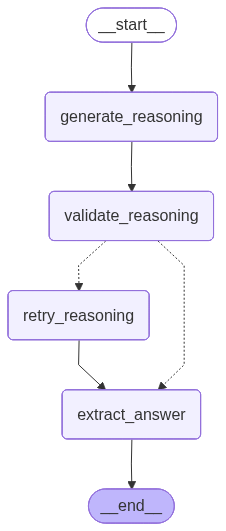

Step 1: Calculate the total distance traveled by the train.
→ The train travels 120 km in the first part of the journey and 80 km in the second part.
→ Total distance = 120 km + 80 km
→ Total distance = 200 km
Step 2: Calculate the total time taken for the entire journey.
→ The train takes 2 hours for the first part and 1.5 hours for the second part.
→ Total time = 2 hours + 1.5 hours
→ Total time = 3.5 hours
Step 3: Calculate the average speed for the entire journey.
→ Average speed is given by the formula: Average speed = Total distance / Total time
→ Average speed = 200 km / 3.5 hours
→ Average speed = 57.14 km/h (rounded to two decimal places)

Intermediate Conclusion: The average speed of the train for the entire journey is 57.14 km/h.
****************************************************************************************************
Answer: 57.14 km/h
Steps: 3
Confidence: 95%


In [11]:
graph = build_cot_graph()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

result = graph.invoke({
    "problem": "A train travels 120km in 2 hours, then 80km in 1.5 hours. What is its average speed for the entire journey?",
    "problem_type": "math",
    "reasoning_chain": "",
    "reasoning_steps": [],
    "is_valid_reasoning": False,
    "final_answer": "",
    "confidence": 0.0,
    "retry_count": 0
})

for i in result["reasoning_steps"]:
    print(i)
print("*"*100)

print(f"Answer: {result['final_answer']}")
print(f"Steps: {len(result['reasoning_steps'])}")
print(f"Confidence: {result['confidence']:.0%}")